In [1]:
import simpful as sf
import numpy as np
import matplotlib.pyplot as plt

# A forma correta na versão atual é inicializar sem argumentos extras
FS = sf.FuzzySystem() 
print("Simpful carregado com sucesso!")

  ____  __  _  _  ____  ____  _  _  __   
 / ___)(  )( \/ )(  _ \(  __)/ )( \(  ) v2.12.0 
 \___ \ )( / \/ \ ) __/ ) _) ) \/ (/ (_/\ 
 (____/(__)\_)(_/(__)  (__)  \____/\____/

 https://github.com/aresio/simpful

Simpful carregado com sucesso!


In [2]:
# VARIÁVEL 1: TEMPERATURA DA MASSA DE VIDRO ESCOANDO (1300 - 1550°C)
# Temperaturas maiores ou menores são ruins.
T_vidro_baixa = sf.FuzzySet(function=sf.Triangular_MF(a=1300, b=1350, c=1400), term="viscoso")
T_vidro_ideal = sf.FuzzySet(function=sf.Triangular_MF(a=1380, b=1425, c=1470), term="ideal")
T_vidro_alta  = sf.FuzzySet(function=sf.Triangular_MF(a=1450, b=1500, c=1550), term="fluido")
FS.add_linguistic_variable("Temp_Vidro", sf.LinguisticVariable([T_vidro_baixa, T_vidro_ideal, T_vidro_alta], universe_of_discourse=[1300, 1600]))

In [3]:
# VARIÁVEL 2: TENDÊNCIA (O fator TEMPO / Velocidade de mudança)
# Aqui medimos quantos graus a temperatura sobe ou desce por minuto (°C/min)
# Se a massa está "esfriando rápido", o escoamento vai travar logo.
V_esfriando = sf.FuzzySet(function=sf.Triangular_MF(a=-10, b=-10, c=0), term="esfriando")
V_estavel   = sf.FuzzySet(function=sf.Triangular_MF(a=-2, b=0, c=2), term="estavel")
V_aquecendo = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=10, c=10), term="aquecendo")
FS.add_linguistic_variable("Tendencia", sf.LinguisticVariable([V_esfriando, V_estavel, V_aquecendo], universe_of_discourse=[-10, 10]))

In [4]:
# VARIÁVEL 3: TEMPERATURA DO SENSOR DE NÍVEL
# O sensor deve operar abaixo de 80°C, caso não, o sensor será queimado
S_seguro = sf.FuzzySet(function=sf.Trapezoidal_MF(a=0, b=0, c=50, d=70), term="seguro")
S_alerta = sf.FuzzySet(function=sf.Trapezoidal_MF(a=60, b=75, c=80, d=80), term="perigo")
FS.add_linguistic_variable("Temp_Sensor", sf.LinguisticVariable([S_seguro, S_alerta], universe_of_discourse=[0, 80]))

In [5]:
# VARIÁVEL DE SAÍDA: DISTRIBUIÇÃO DO FLUXO DE RESFRIAMENTO
# Definimos a intensidade da ventoinha de 0 a 100%
#Resf_baixo  = sf.FuzzySet(function=sf.Triangular_MF(a=0, b=0, c=60), term="baixo")
#Resf_maximo = sf.FuzzySet(function=sf.Triangular_MF(a=40, b=100, c=100), term="maximo")
#FS.add_linguistic_variable("Resfriamento", sf.LinguisticVariable([Resf_baixo, Resf_maximo], universe_of_discourse=[0, 100]))

In [21]:
# VARIÁVEL DE SAÍDA: RESFRIAMENTO (Ajustada)
# Reduzi a sobreposição para o centroide não ser puxado para baixo
# Agora o 'baixo' morre em 30 e o 'maximo' começa em 70
out1 = sf.FuzzySet(function=sf.Trapezoidal_MF(a=0, b=0, c=10, d=30), term="baixo")
out2 = sf.FuzzySet(function=sf.Trapezoidal_MF(a=70, b=90, c=100, d=100), term="maximo")
FS.add_linguistic_variable("Resfriamento", sf.LinguisticVariable([out1, out2], universe_of_discourse=[0, 100]))

In [22]:
# VARIÁVEL DE SAÍDA: DISTRIBUIÇÃO DO FLUXO DE RESFRIAMENTO
# Melhoria: Bases dos trapezoides ajustadas para controle mais agressivo (86%+)
#Resf_baixo  = sf.FuzzySet(function=sf.Trapezoidal_MF(a=0, b=0, c=10, d=30), term="baixo")
#Resf_maximo = sf.FuzzySet(function=sf.Trapezoidal_MF(a=70, b=90, c=100, d=100), term="maximo")
#FS.add_linguistic_variable("Resfriamento", sf.LinguisticVariable([Resf_baixo, Resf_maximo], universe_of_discourse=[0, 100]))

In [23]:
# BASE DE REGRAS (Lógica de Especialista)
# CORREÇÃO: Ajustado para usar 'fluido' e 'viscoso' conforme definido nos FuzzySets acima
R1 = "IF (Temp_Sensor IS perigo) THEN (Resfriamento IS maximo)"
R2 = "IF (Temp_Vidro IS fluido) AND (Tendencia IS aquecendo) AND (Temp_Sensor IS seguro) THEN (Resfriamento IS maximo)"
R3 = "IF (Temp_Vidro IS ideal) AND (Tendencia IS estavel) AND (Temp_Sensor IS seguro) THEN (Resfriamento IS baixo)"
R4 = "IF (Tendencia IS esfriando) AND (Temp_Sensor IS seguro) THEN (Resfriamento IS baixo)"

FS.add_rules([R1, R2, R3, R4])

In [24]:
# --- TESTE DOS SENSORES ---
FS.set_variable("Temp_Vidro", 1480)  
FS.set_variable("Tendencia", 2)      
FS.set_variable("Temp_Sensor", 40)   

resultado = FS.inference()
print(f"--- RESULTADO DA INFERÊNCIA ---")
print(f"Potência de Resfriamento: {resultado['Resfriamento']:.2f}%")

--- RESULTADO DA INFERÊNCIA ---
Potência de Resfriamento: 86.00%


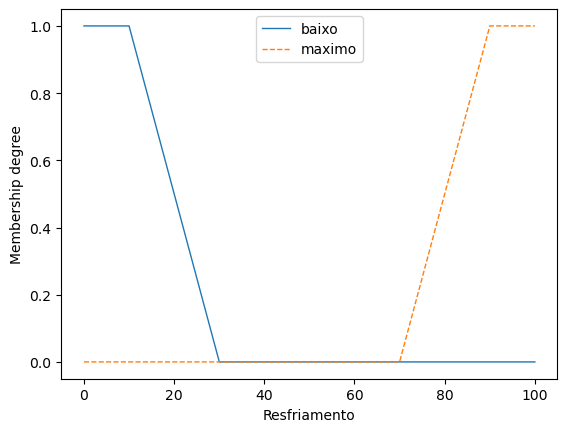

In [25]:
FS.plot_variable("Resfriamento")